# econcharts Demo

This notebook demonstrates the features of the `econcharts` library for creating sharp, professional economic charts.

## Features Demonstrated

1. **Chart Generation**: Single and multi-chart layouts
2. **Scale Alignment**: Proper axis scaling for all data points
3. **Hover Tooltips**: Interactive data point display
4. **Zoom Functionality**: Drag-to-zoom and double-click reset
5. **Dark Theme**: Modern dark color scheme
6. **Customization**: Custom colors and styling
7. **Recession Shading**: NBER recession periods visualization

## Interactive Features

All charts in this notebook support:

- **Hover**: Move your mouse over the chart to see data values
- **Zoom**: Click and drag to select an area to zoom in
- **Pan**: After zooming, drag to pan around
- **Reset**: Double-click to reset the view
- **Legend Toggle**: Click legend items to show/hide series

In [1]:
from datetime import datetime, timedelta

from econcharts import EconChart, EconBoard, Data
from econcharts.fred import (
    fetch_gdp, fetch_inflation, fetch_unemployment,
    fetch_fed_funds, fetch_sp500, fetch_treasury_10y,
    list_series
)
from econcharts.recessions import NBER_RECESSIONS, get_recessions_in_range

from IPython.display import Image, display, HTML

print("Available FRED series:")
for name, info in list_series().items():
    print(f"  {name}: {info['name']} ({info['frequency']})")

print(f"\nNBER Recessions available: {len(NBER_RECESSIONS)} periods")

Available FRED series:
  GDP: Real GDP Growth (quarterly)
  CPI: Consumer Price Index (monthly)
  INFLATION: Inflation Rate (monthly)
  UNEMPLOYMENT: Unemployment Rate (monthly)
  FEDFUNDS: Federal Funds Rate (monthly)
  TREASURY_10Y: 10-Year Treasury Rate (daily)
  SP500: S&P 500 Index (daily)

NBER Recessions available: 12 periods


## Economic Data from FRED

This notebook uses real economic data from FRED (Federal Reserve Economic Data).
The data is fetched via `pandas_datareader` and cached locally for offline use.

In [2]:
# Fetch real economic data from FRED
# Data is cached locally for offline use

# Real GDP Growth (quarterly, % change)
gdp_dates, gdp_values = fetch_gdp(start="2000-01-01")
first_q = (gdp_dates[0].month - 1) // 3 + 1
print(f"GDP: {len(gdp_dates)} quarters from {gdp_dates[0].year}-Q{first_q} to {gdp_dates[-1].year}")

# Inflation Rate (monthly, % YoY)
inf_dates, inf_values = fetch_inflation(start="2000-01-01")
print(f"Inflation: {len(inf_dates)} months")

# Unemployment Rate (monthly, %)
unemp_dates, unemp_values = fetch_unemployment(start="2000-01-01")
print(f"Unemployment: {len(unemp_dates)} months")

# Federal Funds Rate (monthly, %)
fedfunds_dates, fedfunds_values = fetch_fed_funds(start="2000-01-01")
print(f"Fed Funds: {len(fedfunds_dates)} months")

# S&P 500 Index (daily)
sp500_dates, sp500_values = fetch_sp500(start="2020-01-01")
print(f"S&P 500: {len(sp500_dates)} days")

# 10-Year Treasury Rate (daily, %)
treasury_dates, treasury_values = fetch_treasury_10y(start="2020-01-01")
print(f"10Y Treasury: {len(treasury_dates)} days")

GDP: 103 quarters from 2000-Q1 to 2025
Inflation: 291 months
Unemployment: 311 months
Fed Funds: 312 months
S&P 500: 1522 days
10Y Treasury: 1513 days


## 1. Single Chart - GDP Growth

A simple chart showing GDP growth rate over time.

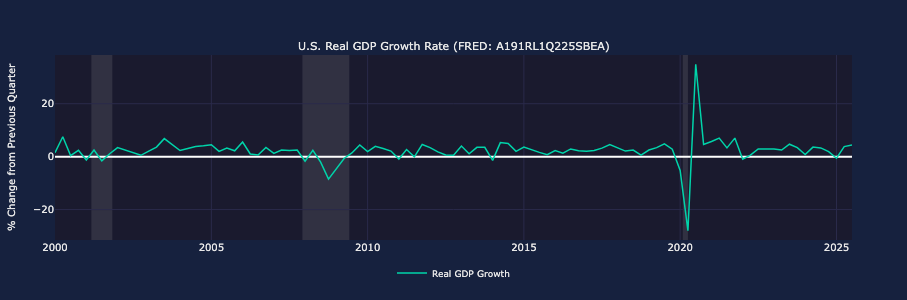

In [3]:
# Single chart with real GDP data
# EconChart can be displayed directly without wrapping in EconBoard
chart = EconChart(
    Data(x=gdp_dates, y=gdp_values, name='Real GDP Growth', color='teal'),
    title='U.S. Real GDP Growth Rate (FRED: A191RL1Q225SBEA)',
    y_label='% Change from Previous Quarter',
    horizontal_line=0,
)
chart.show()  # Crosshair and recession shading enabled by default

## 2. Multi-Chart Layout

A dashboard with three synchronized charts showing GDP, Inflation, and Unemployment.

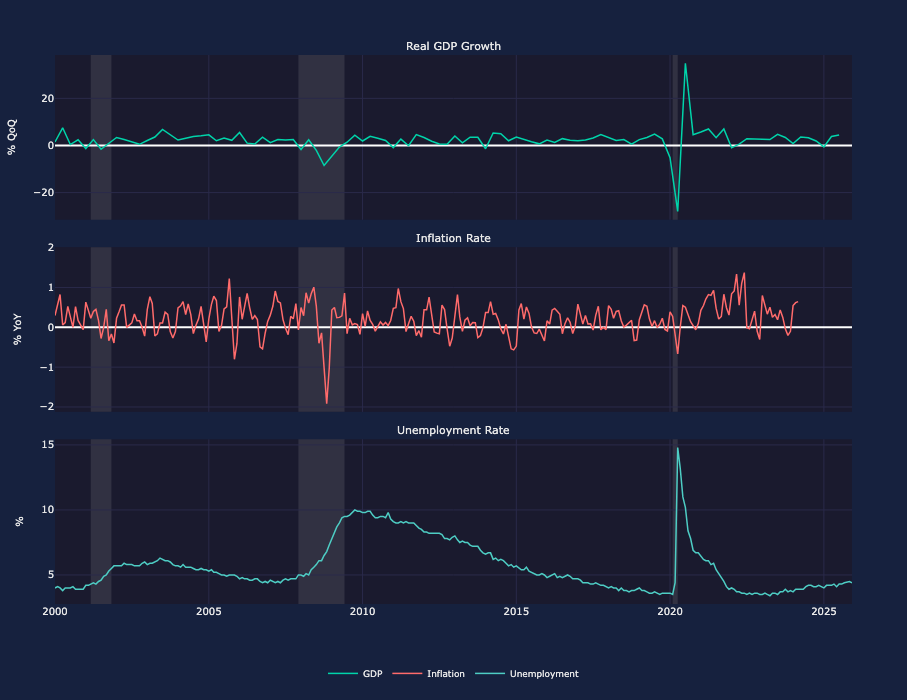

In [12]:
# Multi-chart layout with real economic data
gdp_chart = EconChart(
    Data(x=gdp_dates, y=gdp_values, name='GDP', color='teal'),
    title='Real GDP Growth',
    y_label='% QoQ',
    horizontal_line=0,
)

inflation_chart = EconChart(
    Data(x=inf_dates, y=inf_values, name='Inflation', color='coral'),
    title='Inflation Rate',
    y_label='% YoY',
    horizontal_line=2.0,  # Fed's 2% inflation target
)

unemployment_chart = EconChart(
    Data(x=unemp_dates, y=unemp_values, name='Unemployment', color='sky'),
    title='Unemployment Rate',
    y_label='%',
)

# Crosshair and recession shading are enabled by default
board = EconBoard(
    gdp_chart, inflation_chart, unemployment_chart,
    height=700,
    legend='bottom',
)
board.show()

## 3. Logarithmic Scale Chart

Stock prices often look better on a log scale to show percentage changes more accurately.

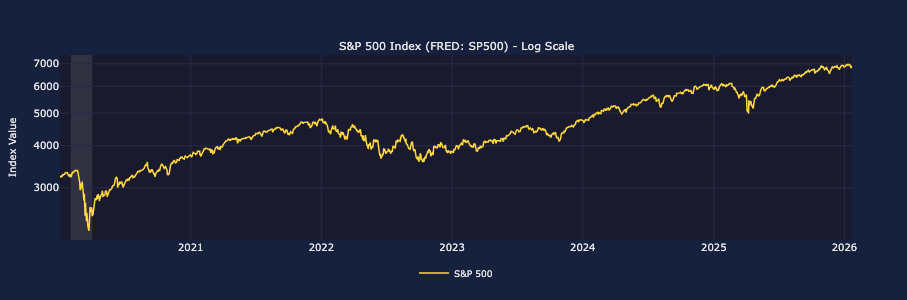

In [5]:
# S&P 500 on log scale - perfect for showing long-term growth
chart = EconChart(
    Data(x=sp500_dates, y=sp500_values, name='S&P 500', color='gold'),
    title='S&P 500 Index (FRED: SP500) - Log Scale',
    y_label='Index Value',
    y_scale='log',
)
chart.show(height=400)  # Direct display

## 4. Multiple Series Comparison

Comparing EFFR and DGS10 on the same chart.

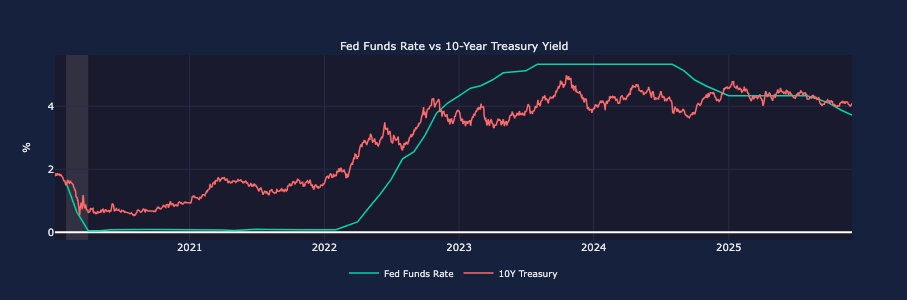

In [6]:
# Comparing Fed Funds Rate and 10-Year Treasury
# Use the same date range for comparison
common_start = max(min(fedfunds_dates), min(treasury_dates))
common_end = min(max(fedfunds_dates), max(treasury_dates))

# Filter to common range
ff_filtered = [(d, v) for d, v in zip(fedfunds_dates, fedfunds_values) 
               if common_start <= d <= common_end]
tr_filtered = [(d, v) for d, v in zip(treasury_dates, treasury_values)
               if common_start <= d <= common_end]

chart = EconChart(
    Data(x=[d for d, _ in ff_filtered], y=[v for _, v in ff_filtered], 
         name='Fed Funds Rate', color='teal'),
    Data(x=[d for d, _ in tr_filtered], y=[v for _, v in tr_filtered],
         name='10Y Treasury', color='coral'),
    title='Fed Funds Rate vs 10-Year Treasury Yield',
    y_label='%',
    horizontal_line=0,
)
chart.show(height=400)  # Direct display

## 5. Custom Color Theme

You can customize the color scheme for different visual styles. Here's a light theme example.

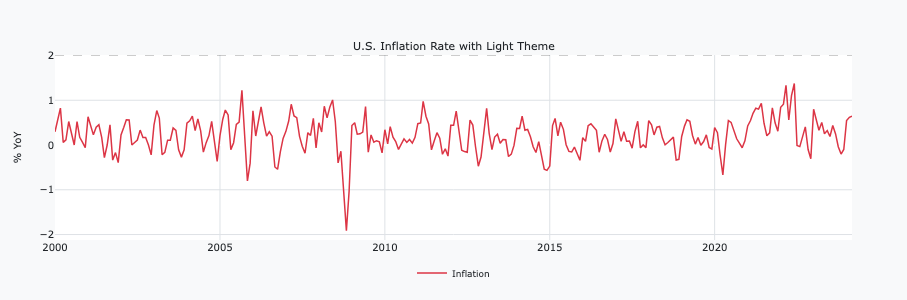

In [7]:
# Custom light theme with real inflation data
light_colors = {
    'background': '#ffffff',
    'paper': '#f8f9fa',
    'grid': '#dee2e6',
    'text': '#212529',
    'spike': 'rgba(0, 0, 0, 0.3)',
    'crosshair': 'rgba(0, 0, 0, 0.3)',
    'zero_line': 'rgba(0, 0, 0, 0.2)',
}

chart = EconChart(
    Data(x=inf_dates, y=inf_values, name='Inflation', color='#dc3545'),
    title='U.S. Inflation Rate with Light Theme',
    y_label='% YoY',
    horizontal_line=2.0,  # Fed target
)
# Pass board options directly to show()
chart.show(height=400, colors=light_colors, show_recessions=False)

## 6. Scatter Plot with Markers

Sometimes you want to show individual data points rather than lines.

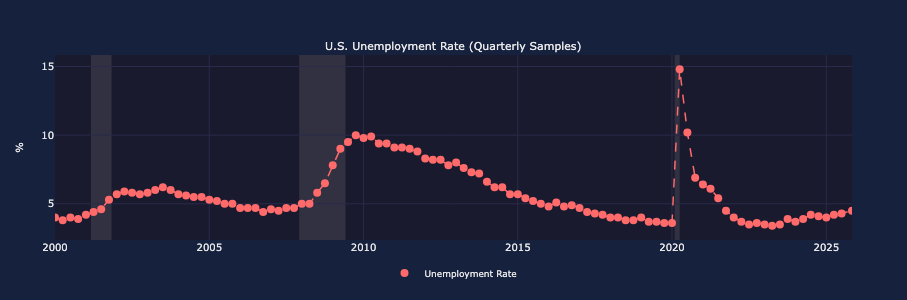

In [8]:
# Scatter plot with quarterly unemployment data points
# Sample to quarterly (every 3rd month)
quarterly_unemp_dates = unemp_dates[::3]
quarterly_unemp_values = unemp_values[::3]

chart = EconChart(
    Data(x=quarterly_unemp_dates, y=quarterly_unemp_values, 
         name='Unemployment Rate', color='coral',
         style='scatter', marker_size=8),
    Data(x=quarterly_unemp_dates, y=quarterly_unemp_values,
         name='Trend', color='coral',
         line_style='dashed', show_in_legend=False),
    title='U.S. Unemployment Rate (Quarterly Samples)',
    y_label='%',
)
chart.show(height=400)  # Direct display

## 7. Auto-Color Assignment

If you don't specify colors, they are auto-assigned alphabetically from the palette.

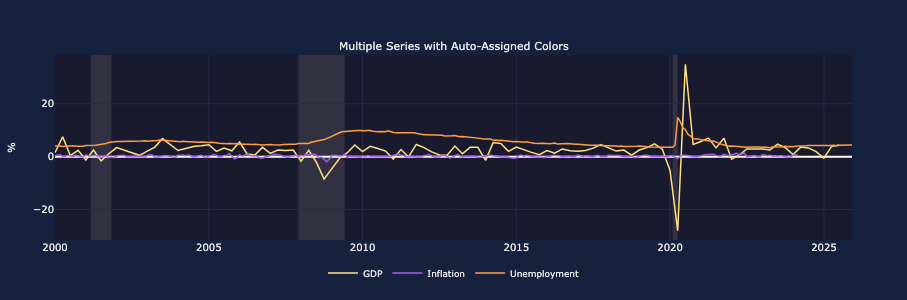

Colors assigned alphabetically from the 68-color palette.


In [9]:
# Auto-color assignment demo
# Colors are assigned alphabetically: amber, amethyst, apricot, bear, blue, bull, ...
chart = EconChart(
    Data(x=gdp_dates, y=gdp_values, name='GDP'),        # Auto: amber
    Data(x=inf_dates, y=inf_values, name='Inflation'),  # Auto: amethyst  
    Data(x=unemp_dates, y=unemp_values, name='Unemployment'),  # Auto: apricot
    title='Multiple Series with Auto-Assigned Colors',
    y_label='%',
)
chart.show(height=400)  # Direct display

print("Colors assigned alphabetically from the 68-color palette.")